In [45]:
import pickle
import pandas as pd
from pathlib import Path

# --- 1. Define the path to your specific .pkl file ---
# Swap 'target' to 'steps' to look at intermediate non-converged iterations!
file_path = Path("../outputs/subneptune_test/steps/M_1.000_Tirr_1100.0_Tint_332.9_Met_0.00_Core_15.0_fsed_1.0_kzz_8.0.pkl")
file_path = Path("../outputs/tests/target/M_1.000_Tirr_1100.0_Tint_332.9_Met_0.00_Core_15.0_fsed_1.0_kzz_8.0.pkl")

# --- 2. Load the Pickle file ---
if file_path.exists():
    with open(file_path, "rb") as f:
        model_data = pickle.load(f)
        
    # --- 3. Extract the contents ---
    # io.py saves parameters under either 'parameters' or 'final_params' depending on the step
    params = model_data.get("parameters", model_data.get("final_params", {}))
    status = model_data.get("status")
    iterations = model_data.get("iterations", model_data.get("iteration"))
    
    # The fully stitched Atmosphere + Interior profile (Pandas DataFrame)
    profile_df = model_data.get("profile", model_data.get("stitched_profile"))
    
    # The raw interior arrays (used for the built-in diagnostic plots)
    interior_raw = model_data.get("interior_raw")
    
    # Synthetic photometry dictionary
    photometry = model_data.get("photometry")
    
    # --- 4. Display Basic Physics Info ---
    print("="*50)
    print(f"🌍 MODEL SUMMARY")
    print("="*50)
    print(f"Status        : {status.upper()} (in {iterations} iterations)")
    print(f"Target Mass   : {params.get('mass', 0):.3f} M_Jup")
    print(f"True Calc Mass: {params.get('true_mass_Mjup', 0):.3f} M_Jup")
    print(f"Core Mass     : {params.get('core_mass_earth', 0)} M_Earth")
    print(f"1-bar Gravity : {params.get('g_1bar', 0):.2f} m/s²")
    print(f"T_int (True)  : {params.get('T_int', 0):.1f} K")
    print("="*50)
    
    # Show the top (atmosphere) and bottom (core) of the continuous profile
    print("\nTop of Atmosphere (Lowest Pressure):")
    display(profile_df.head(3))
    
    print("\nDeep Interior (Highest Pressure):")
    display(profile_df.tail(3))
    
else:
    print(f"❌ File not found: {file_path}")

🌍 MODEL SUMMARY
Status        : CONVERGED (in 3 iterations)
Target Mass   : 1.000 M_Jup
True Calc Mass: 0.990 M_Jup
Core Mass     : 15.0 M_Earth
1-bar Gravity : 16.15 m/s²
T_int (True)  : 332.9 K

Top of Atmosphere (Lowest Pressure):


,Pressure_Pa,Pressure_bar,Radius_m,Temperature_K,Density_kgm3,Gravity_ms2,MolarMass_kgmol
0,0.100000,0.000001,9.301036e+07,735.245461,3.815782e-08,10.576019,0.002333
1,0.129569,0.000001,9.294626e+07,743.514158,4.889379e-08,10.650091,0.002333
2,0.167880,0.000002,9.288190e+07,752.464953,6.259776e-08,10.724739,0.002333



Deep Interior (Highest Pressure):


,Pressure_Pa,Pressure_bar,Radius_m,Temperature_K,Density_kgm3,Gravity_ms2,MolarMass_kgmol
2094,4.748344e+12,4.748344e+07,50600.0,45279.821013,11804.643795,0.164526,NaN
2095,4.748380e+12,4.748380e+07,25600.0,45279.855008,11804.682221,0.082028,NaN
2096,4.748391e+12,4.748391e+07,600.0,45279.865815,11804.694436,0.000147,NaN


In [40]:
model_data.keys()

dict_keys(['status', 'timestamp', 'iteration', 'parameters', 'mass_calculated_mjup', 'mass_error', 'profile', 'atmosphere_raw', 'interior_raw', 'photometry'])

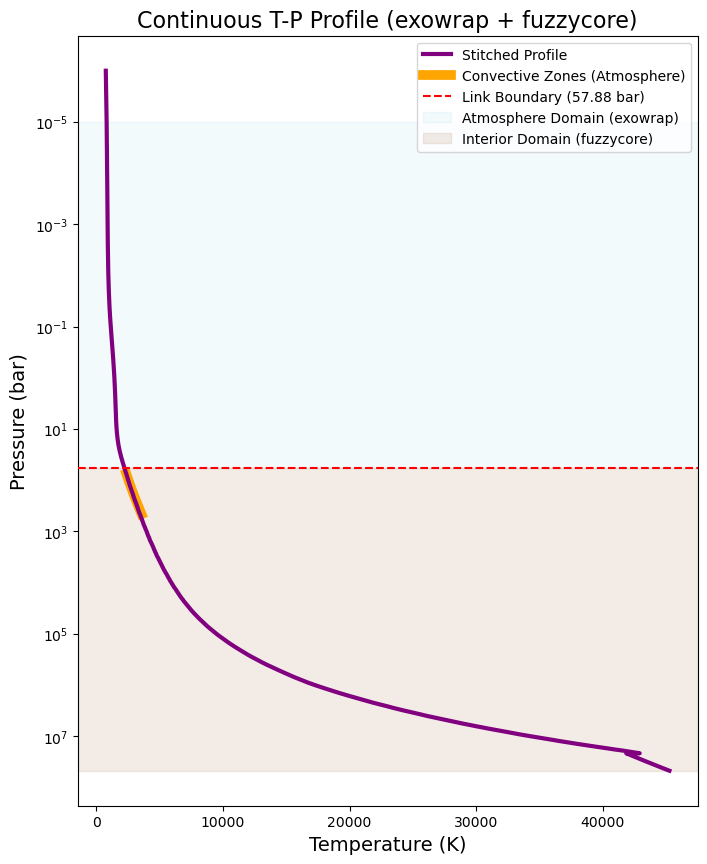

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = model_data['profile']
p_link = model_data['parameters']['p_link_bar']

fig, ax = plt.subplots(figsize=(8, 10))

# 1. Plot the full stitched profile
ax.plot(df['Temperature_K'], df['Pressure_bar'], color='purple', lw=3, zorder=3, label='Stitched Profile')

# 2. Extract and overlay the convective zones from the atmosphere!
atm_raw = model_data['atmosphere_raw']
p_atm_bar = atm_raw['/outputs/levels/pressure'].iloc[0] / 1e5
t_atm = atm_raw['/outputs/levels/temperature'].iloc[0]
is_conv = atm_raw['/outputs/levels/is_convective'].iloc[0].astype(bool)

# Replace all non-convective temperatures with NaN
t_conv = np.where(is_conv, t_atm, np.nan)

# Plot the bold overlay (Matplotlib automatically skips the NaNs!)
ax.plot(t_conv, p_atm_bar, color='orange', lw=7, zorder=2, label='Convective Zones (Atmosphere)')

# 3. Draw a line showing exactly where the two models linked
ax.axhline(p_link, color='red', linestyle='--', zorder=4, label=f'Link Boundary ({p_link:.2f} bar)')

# 4. Format the axes for atmospheric science standards (log pressure, inverted)
ax.set_yscale('log')
ax.invert_yaxis()
ax.set_xlabel("Temperature (K)", fontsize=14)
ax.set_ylabel("Pressure (bar)", fontsize=14)
ax.set_title("Continuous T-P Profile (exowrap + fuzzycore)", fontsize=16)

# 5. Fill background colors to show domains
ax.axhspan(1e-5, p_link, color='skyblue', alpha=0.1, label='Atmosphere Domain (exowrap)')
ax.axhspan(p_link, df['Pressure_bar'].max(), color='saddlebrown', alpha=0.1, label='Interior Domain (fuzzycore)')

ax.legend(loc='upper right')
plt.show()

Figure saved to: ../figures/structure_diagnostics.pdf


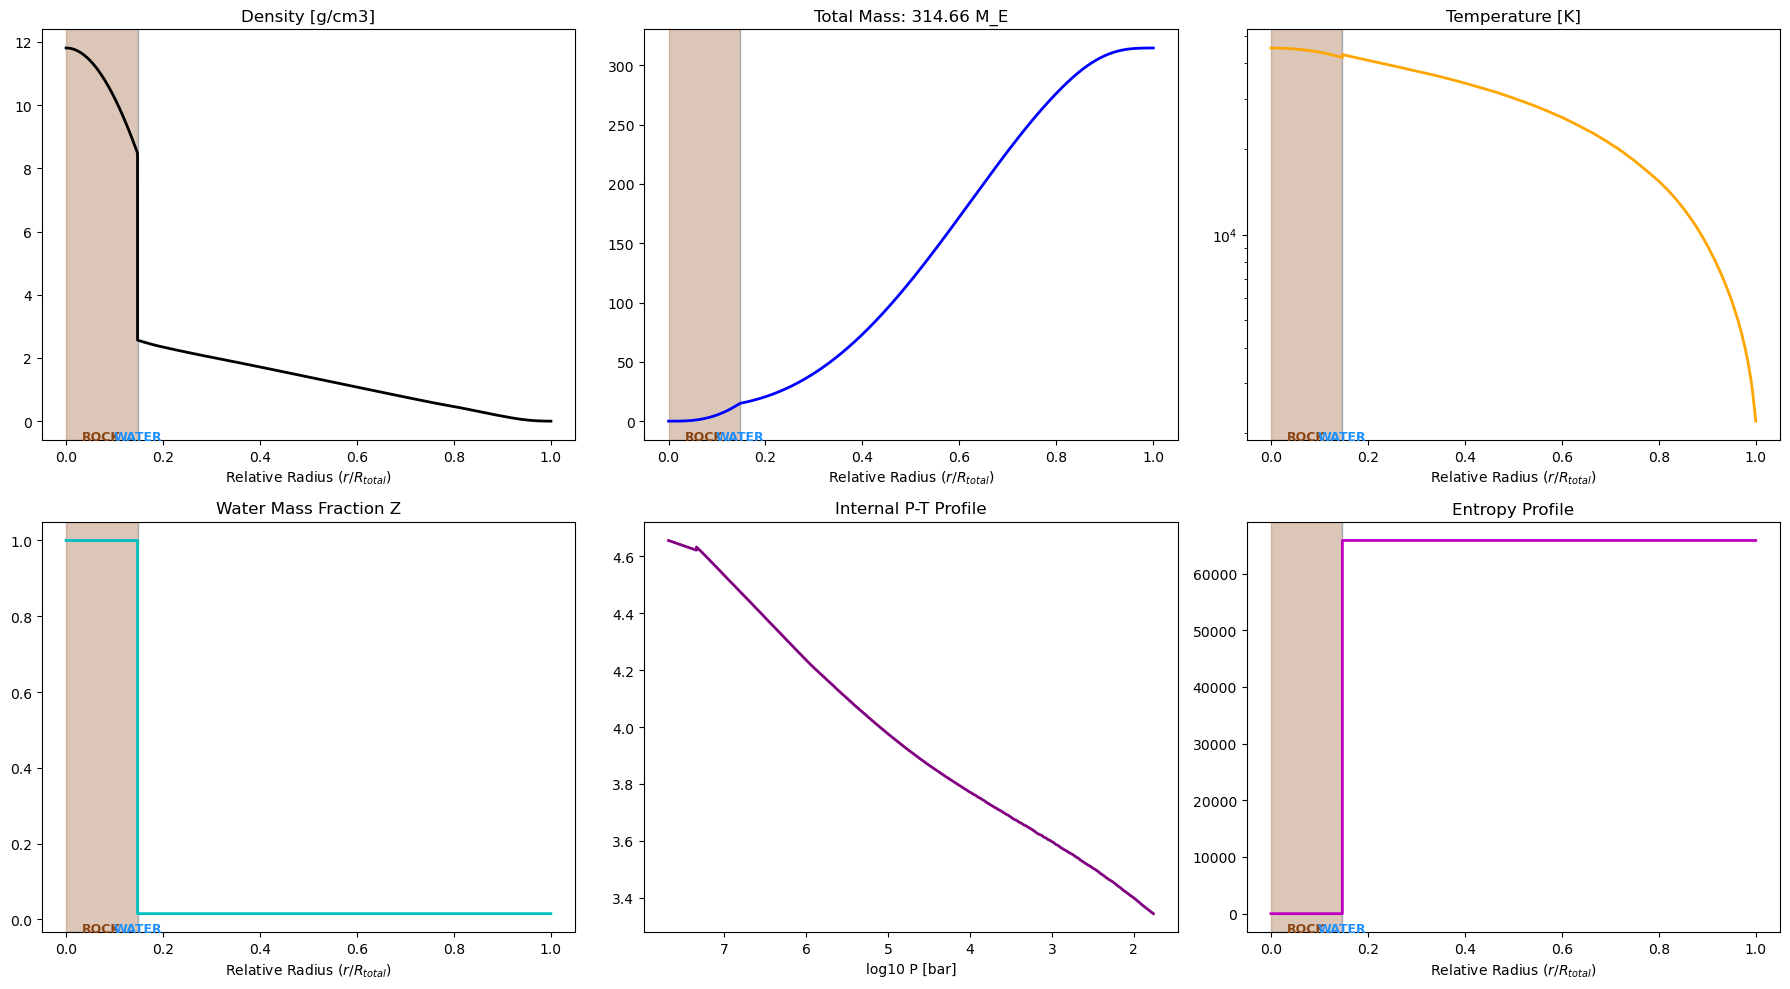

In [47]:
from fuzzycore.plotting import plot_diagnostics

plot_diagnostics(model_data['interior_raw'])